In [ ]:
import gym
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import A2C
from stable_baselines3.common.env_util import make_vec_env
from scipy.stats import sem
import imageio



In [142]:
batch_size = 200

num_episodes = 700
num_runs = 3
episode_rewards = []

all_episode_rewards = []
gif_episode_numbers = [1, 100, 400, num_episodes-1]

for i_runs in range(num_runs):
    all_images_A2C = []
    env = make_vec_env('CartPole-v1', n_envs=1)
    model = A2C("MlpPolicy", env, verbose=0) # A2C model
    episode_rewards = []
    for i_episode in range(num_episodes):
        images = []
        model.learn(total_timesteps=batch_size, reset_num_timesteps=False)
        state = env.reset()
        done = False
        total_reward = 0
        while not done:
            if i_episode in gif_episode_numbers:
                img = env.render()
                images.append(img)
                
            action, _ = model.predict(state, deterministic=True)
            state, reward, done, _ = env.step(action)
            total_reward += reward[0]  # reward is returned as an array
        episode_rewards.append(total_reward)
        
        # Print progress every 100 episodes
        if i_episode % 100 == 0:
            print(f"Episode {i_episode}/{num_episodes}: Total Reward = {total_reward}")
        
        if i_episode in gif_episode_numbers:
            all_images_A2C.append(images)
    
    all_episode_rewards.append(episode_rewards)

Episode 0/700: Total Reward = 27.0
Episode 100/700: Total Reward = 47.0
Episode 200/700: Total Reward = 500.0
Episode 300/700: Total Reward = 500.0
Episode 400/700: Total Reward = 500.0
Episode 500/700: Total Reward = 500.0
Episode 600/700: Total Reward = 500.0
Episode 0/700: Total Reward = 19.0
Episode 100/700: Total Reward = 500.0
Episode 200/700: Total Reward = 51.0
Episode 300/700: Total Reward = 500.0
Episode 400/700: Total Reward = 500.0
Episode 500/700: Total Reward = 460.0
Episode 600/700: Total Reward = 500.0
Episode 0/700: Total Reward = 10.0
Episode 100/700: Total Reward = 340.0
Episode 200/700: Total Reward = 14.0
Episode 300/700: Total Reward = 351.0
Episode 400/700: Total Reward = 500.0
Episode 500/700: Total Reward = 355.0
Episode 600/700: Total Reward = 500.0


In [143]:
def plot_durationss(all_durations_DDQN=None):

    plt.figure(figsize=(10, 6))

    all_durations_DDQN = np.array(all_durations_DDQN)
    mean_durations_DDQN = np.mean(all_durations_DDQN, axis=0)
    confidence_intervals_DDQN = sem(all_durations_DDQN, axis=0)  # Standard error of mean
    x_DDQN = np.arange(all_durations_DDQN.shape[1])
    plt.plot(x_DDQN, mean_durations_DDQN, label="A2C duration", color='green')
    plt.fill_between(x_DDQN, mean_durations_DDQN - confidence_intervals_DDQN, mean_durations_DDQN + confidence_intervals_DDQN, alpha=0.3, color='green')
    
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.title("A2C mean reward")
    plt.legend()
    plt.grid()
    plt.show()
    


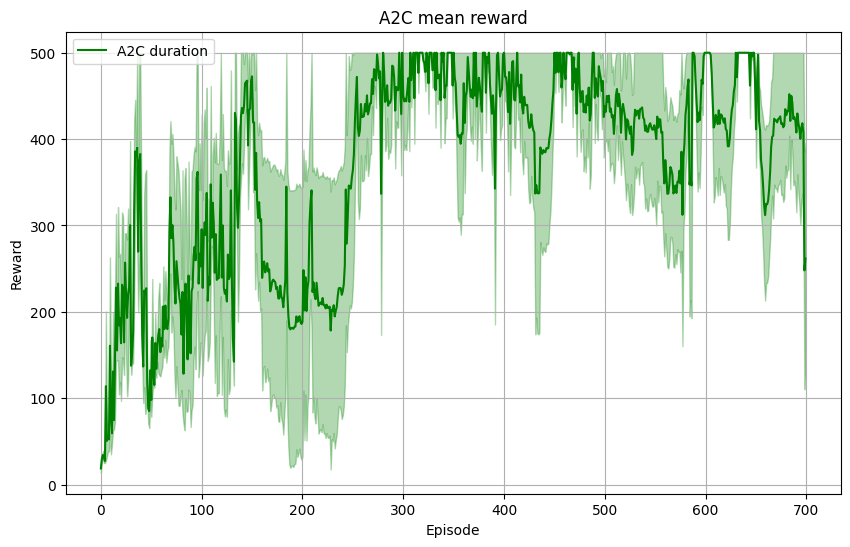

In [144]:
plot_durationss(all_episode_rewards)

In [133]:
# Visualize
for i in [1, 2, 3, 4]:
    images = all_images_A2C[i-1]
    output_filename = f'cartpole_A2C{i}.mp4'
    imageio.mimsave(output_filename, [np.array(img) for img in images], fps=30)


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input ima

In [5]:
from stable_baselines3 import A2C
from stable_baselines3.common.env_util import make_vec_env

# Parallel environments
vec_env = make_vec_env("CartPole-v1", n_envs=1)

model = A2C("MlpPolicy", vec_env, verbose=1)
model.learn(total_timesteps=75000)
model.save("a2c_cartpole")



Using cpu device
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 48.2     |
|    ep_rew_mean        | 48.2     |
| time/                 |          |
|    fps                | 1230     |
|    iterations         | 100      |
|    time_elapsed       | 0        |
|    total_timesteps    | 500      |
| train/                |          |
|    entropy_loss       | -0.643   |
|    explained_variance | 0.16     |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | 1.63     |
|    value_loss         | 10.8     |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 43.1     |
|    ep_rew_mean        | 43.1     |
| time/                 |          |
|    fps                | 1245     |
|    iterations         | 200      |
|    time_elapsed       | 0        |
|    total_timesteps    | 1000     |
| train/             

In [ ]:
del model # remove to demonstrate saving and loading

model = A2C.load("a2c_cartpole")

obs = vec_env.reset()
while True:
    action, _states = model.predict(obs)
    obs, rewards, dones, info = vec_env.step(action)
    vec_env.render("human")